# 1.2 — The Philosophy of Design

Five principles define how aircraft designers approach their work.

**Design is iterative.** No aircraft emerges from a single pass through the engineering process. The designer begins with rough estimates, refines them, discovers inconsistencies, and loops back to correct them. Torenbeek describes this as *progressive refinement* — each iteration increases fidelity and reduces uncertainty {cite}`torenbeek2013`.

**There is no single right answer.** Competing requirements — speed, range, payload, cost, safety — cannot all be simultaneously maximised. Every design is a compromise. The designer's task is to find the best compromise for the stated mission {cite}`raymer2018`.

**Educated judgment is the engineer's most critical tool.** Early-stage design involves incomplete information by definition. The engineer must make assumptions — informed by historical data, physical reasoning, and experience. The goal is not to avoid assumptions, but to make them deliberately, document them clearly, and track their consequences {cite}`raymer2018`.

**Seek information from diverse sources.** No single reference covers every aspect of aircraft design. Aerodynamics texts, structural handbooks, propulsion databases, historical data, and regulatory documents must all be consulted simultaneously {cite}`nicolai2002`.

**Apply an engineering mindset.** Identify the need → define requirements → generate candidates → analyse → select → iterate. This disciplined approach distinguishes structured engineering from guesswork {cite}`anderson2012`.

```{tip}
Design involves a *multitude of ways* to solve the problem — there is no one 'right' answer. You will need to make educated guesses throughout, and seek information from a range of resources. Embrace the iteration.
```

## The Iterative Design Loop

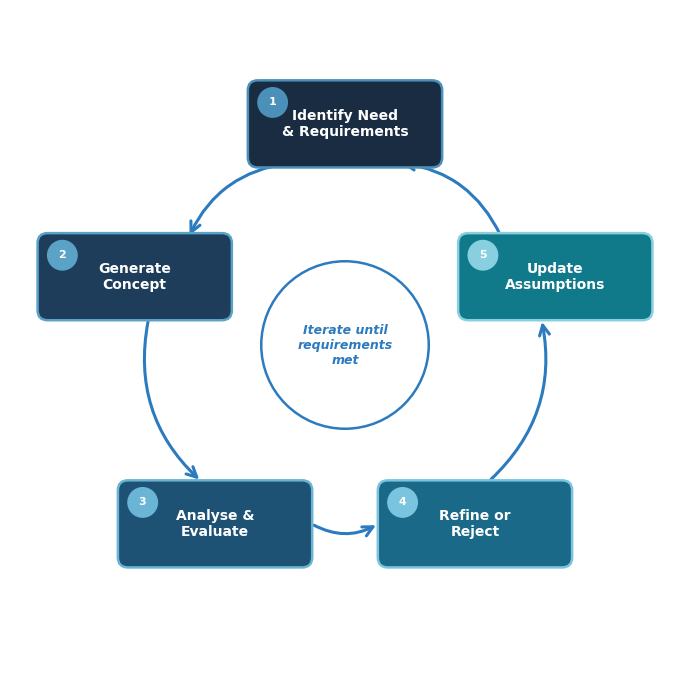

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams['savefig.facecolor'] = 'none'


def box_edge_point(cx, cy, toward_x, toward_y, hw=1.3, hh=0.5, gap=0.14):
 dx, dy = toward_x - cx, toward_y - cy
 length = (dx**2 + dy**2)**0.5
 if length < 1e-9:
 return cx, cy
 tx = (hw / abs(dx)) if abs(dx) > 1e-9 else float('inf')
 ty = (hh / abs(dy)) if abs(dy) > 1e-9 else float('inf')
 t = min(tx, ty) + gap / length
 return cx + t * dx, cy + t * dy


fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, 6)[:-1]
r, cx, cy = 3.3, 5.0, 5.0
positions = [(cx + r * np.cos(a), cy + r * np.sin(a)) for a in angles]

labels = [
 'Identify Need\n& Requirements',
 'Generate\nConcept',
 'Analyse &\nEvaluate',
 'Refine or\nReject',
 'Update\nAssumptions',
]
colours = ['#1a2c42', '#1d3d5a', '#1e5275', '#1a6988', '#107a8b']
edge_colours = ['#4a90b8', '#5aa3c7', '#6ab5d5', '#7ac4df', '#88cfdf']
bw, bh = 2.6, 1.0
node_centres = {}

for i, ((nx, ny), lbl) in enumerate(zip(positions, labels)):
 box = mpatches.FancyBboxPatch(
 (nx - bw / 2, ny - bh / 2), bw, bh,
 boxstyle='round,pad=0.15',
 facecolor=colours[i], edgecolor=edge_colours[i], lw=1.8, zorder=3)
 ax.add_patch(box)
 ax.text(nx, ny, lbl, fontsize=10, ha='center', va='center',
 color='white', fontweight='bold', multialignment='center', zorder=4)
 node_centres[lbl] = (nx, ny)
 circ = plt.Circle((nx - bw / 2 + 0.22, ny + bh / 2 - 0.18), 0.22,
 color=edge_colours[i], zorder=5)
 ax.add_patch(circ)
 ax.text(nx - bw / 2 + 0.22, ny + bh / 2 - 0.18, str(i + 1),
 fontsize=8, ha='center', va='center',
 color='white', fontweight='bold', zorder=6)

for i in range(len(labels)):
 src = node_centres[labels[i]]
 dst = node_centres[labels[(i + 1) % len(labels)]]
 ax.annotate('',
 xy=box_edge_point(*dst, *src),
 xytext=box_edge_point(*src, *dst),
 arrowprops=dict(
 arrowstyle='->', color='#2c7bbf', lw=2.2,
 connectionstyle='arc3,rad=0.28',
 mutation_scale=18),
 zorder=1)

ax.add_patch(plt.Circle((cx, cy), 1.25, fill=False,
 edgecolor='#2c7bbf', lw=1.8, zorder=2))
ax.text(cx, cy, 'Iterate until\nrequirements\nmet',
 fontsize=9, ha='center', va='center',
 color='#2c7bbf', style='italic', fontweight='semibold',
 multialignment='center', zorder=3)

plt.tight_layout()
plt.show()

*Figure 1 — The Iterative Design Loop. Each step feeds the next; the cycle repeats until the design satisfies all requirements. Adapted from {cite}`raymer2018` and {cite}`torenbeek2013`.*

```{bibliography}
:filter: docname in docnames
```

## Requirements: The Bridge Between Need and Design

Before any sizing or geometry work begins, the identified need must be translated into **engineering requirements** — measurable, verifiable statements of what the aircraft must do. Requirements are not wishes; they are the contractual foundation of the design {cite}`raymer2018`.

A well-formed requirement has three qualities: it is **quantified** (a number, not a direction), **verifiable** (testable by analysis or measurement), and **traceable** (linked back to a specific customer or mission need). "Fly fast" is not a requirement. "Maximum cruise speed ≥ 55 m/s at sea level" is.

Requirements typically fall into two categories:

- **Performance requirements** define what the aircraft must achieve: endurance, range, payload mass, maximum speed, service ceiling, takeoff distance.
- **Operational requirements** define how and where it operates: runway type, operating altitude band, temperature range, maintenance interval, storage constraints.

An important and often misunderstood distinction arises between **endurance** and **range** — they are not interchangeable {cite}`gabefpv2026`. Endurance (total time aloft) is maximised by minimising power required, which drives the aircraft toward low speed and high aerodynamic efficiency at a specific condition. Range (total distance covered) is maximised by minimising energy per unit distance, which drives toward a different speed and a different L/D optimum. Specifying one when you mean the other will produce a correctly designed aircraft for the wrong mission.

The question of *who* defines the requirements — "Who's the customer?" — is equally important {cite}`gabefpv2026`. For a military UAV, the customer is a program office with a formal requirements document. For a commercial transport, it is an airline's fleet-planning team. For an academic competition aircraft (such as AIAA DBF), it is a scoring rulebook. Misidentifying the customer, or failing to interrogate their real needs, is one of the most common sources of design failure.

```{warning}
Requirements that conflict must be resolved by the customer *before* design begins, not discovered by the engineer *during* design. A requirement for maximum endurance and minimum weight, without a payload mass specified, is undefined. Start every project by stress-testing the requirements document for gaps and contradictions.
```